# Análise Completa do Campeonato Brasileiro
Notebook com análises estatísticas, gráficos e correlações.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

dados = pd.read_csv('train.csv', sep=';', encoding='latin1')

print(dados.head())

    Ano          Clube  Posicao  Investimento_Milhoes  Gols_Feitos  \
0  2014       Flamengo        1                   182           63   
1  2014      Palmeiras        2                   268           55   
2  2014      São Paulo        3                   294           45   
3  2014    Corinthians        4                   179           74   
4  2014  Internacional        5                   229           36   

   Gols_Sofridos  Saldo_Gols  Pontos  
0             34          29      52  
1             58          -3      63  
2             30          15      68  
3             43          31      47  
4             43          -7      74  


In [85]:
# Remover acentos dos nomes dos clubes
dados['Clube'] = dados['Clube'].apply(
    lambda x: unicodedata.normalize('NFKD', str(x))
    .encode('ASCII', 'ignore')
    .decode('utf-8')
)


In [86]:
# Ajustando posições automaticamente pela pontuação
dados['Posicao'] = (
    dados.groupby('Ano')['Pontos']
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Ordenando tabela
dados = dados.sort_values(['Ano', 'Posicao'])

print(dados[['Ano', 'Clube', 'Pontos', 'Posicao']].head(20))

     Ano          Clube  Pontos  Posicao
5   2014         Gremio      77        1
4   2014  Internacional      74        2
6   2014    Atletico-MG      71        3
2   2014      Sao Paulo      68        4
1   2014      Palmeiras      63        5
9   2014       Botafogo      62        6
7   2014         Santos      60        7
0   2014       Flamengo      52        8
8   2014     Fluminense      51        9
3   2014    Corinthians      47       10
15  2015         Gremio      78        1
16  2015    Atletico-MG      75        2
14  2015  Internacional      73        3
11  2015      Palmeiras      72        4
10  2015       Flamengo      70        5
19  2015       Botafogo      70        5
12  2015      Sao Paulo      61        6
18  2015     Fluminense      60        7
17  2015         Santos      58        8
13  2015    Corinthians      46        9


## Estrutura da Base

In [87]:
print(dados.info())

print(dados.describe())

<class 'pandas.DataFrame'>
Index: 100 entries, 5 to 98
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Ano                   100 non-null    int64
 1   Clube                 100 non-null    str  
 2   Posicao               100 non-null    int64
 3   Investimento_Milhoes  100 non-null    int64
 4   Gols_Feitos           100 non-null    int64
 5   Gols_Sofridos         100 non-null    int64
 6   Saldo_Gols            100 non-null    int64
 7   Pontos                100 non-null    int64
dtypes: int64(7), str(1)
memory usage: 7.0 KB
None
               Ano    Posicao  Investimento_Milhoes  Gols_Feitos  \
count   100.000000  100.00000            100.000000   100.000000   
mean   2018.500000    4.80000            261.650000    58.270000   
std       2.886751    2.59759             89.519974    13.450136   
min    2014.000000    1.00000             88.000000    35.000000   
25%    2016.000000    2.75000   

## Quantidade de clubes únicos

In [88]:
print('Quantidade de clubes:', dados['Clube'].nunique())

print(dados['Clube'].unique())

Quantidade de clubes: 10
<StringArray>
[       'Gremio', 'Internacional',   'Atletico-MG',     'Sao Paulo',
     'Palmeiras',      'Botafogo',        'Santos',      'Flamengo',
    'Fluminense',   'Corinthians']
Length: 10, dtype: str


## Clubes campeões

In [89]:
campeoes = dados[dados['Posicao'] == 1]
print(campeoes[['Ano', 'Clube', 'Pontos']])

     Ano          Clube  Pontos
5   2014         Gremio      77
15  2015         Gremio      78
27  2016         Santos      79
39  2017       Botafogo      77
45  2018         Gremio      76
47  2018         Santos      76
57  2019         Santos      79
64  2020  Internacional      79
73  2021    Corinthians      79
81  2022      Palmeiras      70
83  2022    Corinthians      70
90  2023       Flamengo      77


## Clubes com mais títulos

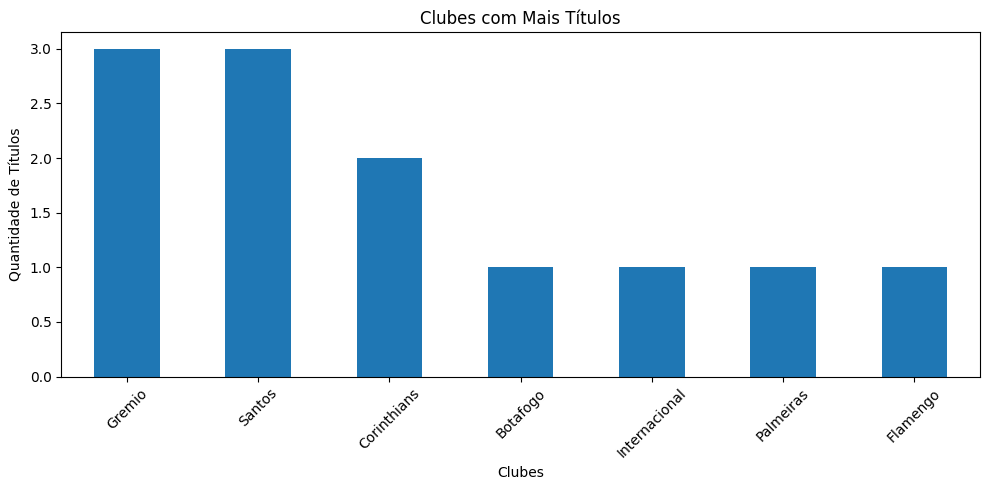

In [90]:
titulos = campeoes['Clube'].value_counts()

plt.figure(figsize=(10,5))
titulos.plot(kind='bar')
plt.title('Clubes com Mais Títulos')
plt.xlabel('Clubes')
plt.ylabel('Quantidade de Títulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Média de pontos por clube

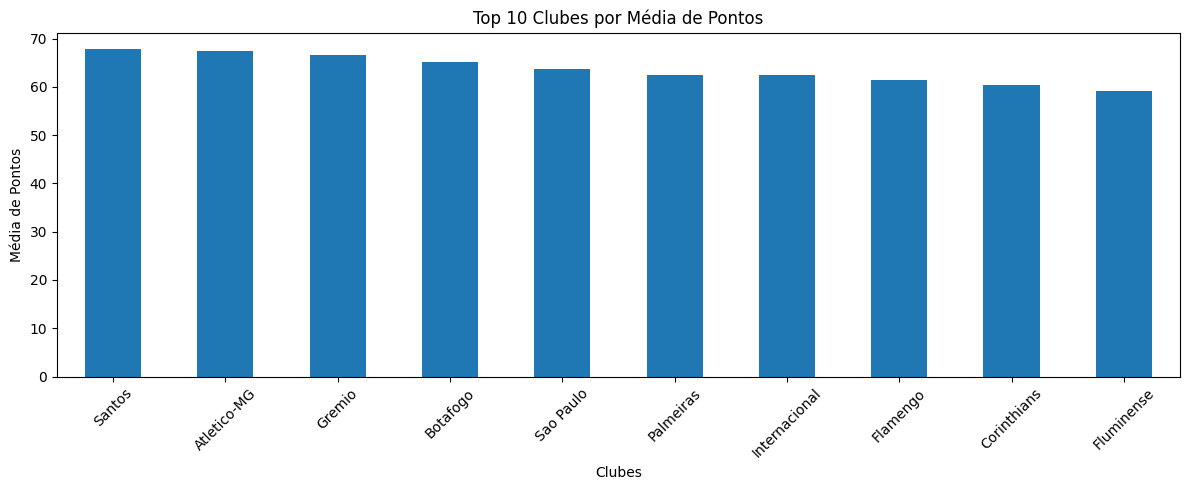

In [91]:
media_pontos = dados.groupby('Clube')['Pontos'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
media_pontos.head(10).plot(kind='bar')
plt.title('Top 10 Clubes por Média de Pontos')
plt.xlabel('Clubes')
plt.ylabel('Média de Pontos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Relação entre investimento e pontos

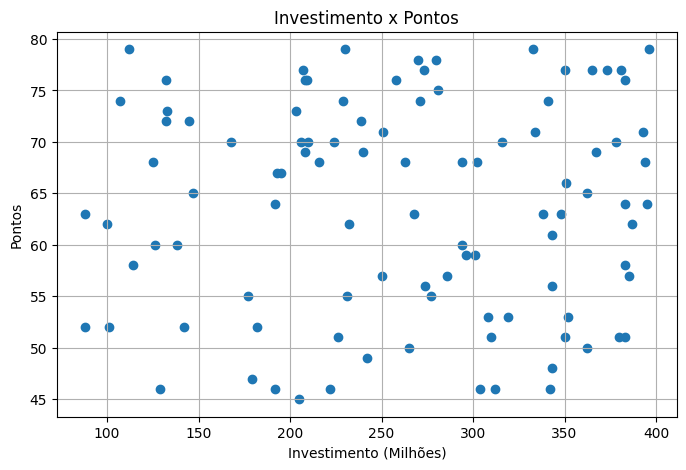

In [92]:
plt.figure(figsize=(8,5))
plt.scatter(dados['Investimento_Milhoes'], dados['Pontos'])
plt.title('Investimento x Pontos')
plt.xlabel('Investimento (Milhões)')
plt.ylabel('Pontos')
plt.grid(True)
plt.show()

## Correlação entre variáveis numéricas

In [93]:
correlacao = dados.corr(numeric_only=True)

print(correlacao)

                           Ano   Posicao  Investimento_Milhoes  Gols_Feitos  \
Ano                   1.000000 -0.020206              0.208042     0.084680   
Posicao              -0.020206  1.000000             -0.053342     0.049265   
Investimento_Milhoes  0.208042 -0.053342              1.000000    -0.009853   
Gols_Feitos           0.084680  0.049265             -0.009853     1.000000   
Gols_Sofridos         0.208341  0.040714             -0.042247    -0.038897   
Saldo_Gols           -0.066919  0.011602              0.019090     0.778758   
Pontos               -0.000512 -0.850171              0.016249    -0.056065   

                      Gols_Sofridos  Saldo_Gols    Pontos  
Ano                        0.208341   -0.066919 -0.000512  
Posicao                    0.040714    0.011602 -0.850171  
Investimento_Milhoes      -0.042247    0.019090  0.016249  
Gols_Feitos               -0.038897    0.778758 -0.056065  
Gols_Sofridos              1.000000   -0.657140  0.013186  
Saldo_G

## Evolução dos gols ao longo dos anos

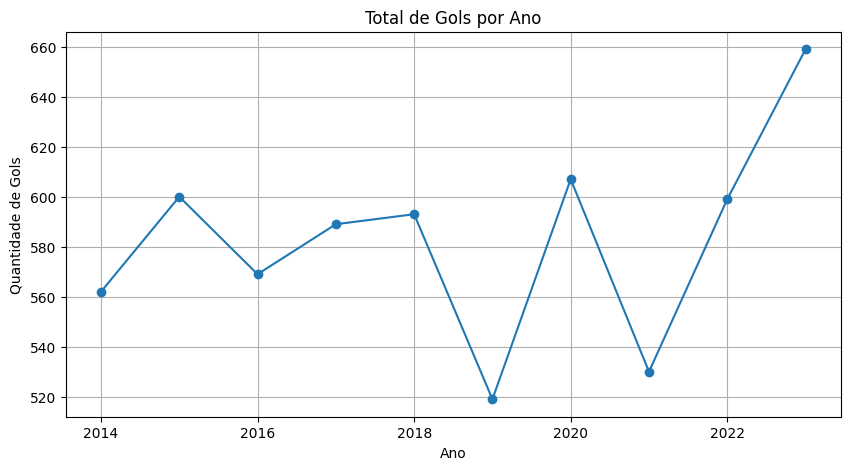

In [94]:
gols_ano = dados.groupby('Ano')['Gols_Feitos'].sum()

plt.figure(figsize=(10,5))
gols_ano.plot(marker='o')
plt.title('Total de Gols por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Gols')
plt.grid(True)
plt.show()

## Clubes com melhor saldo de gols

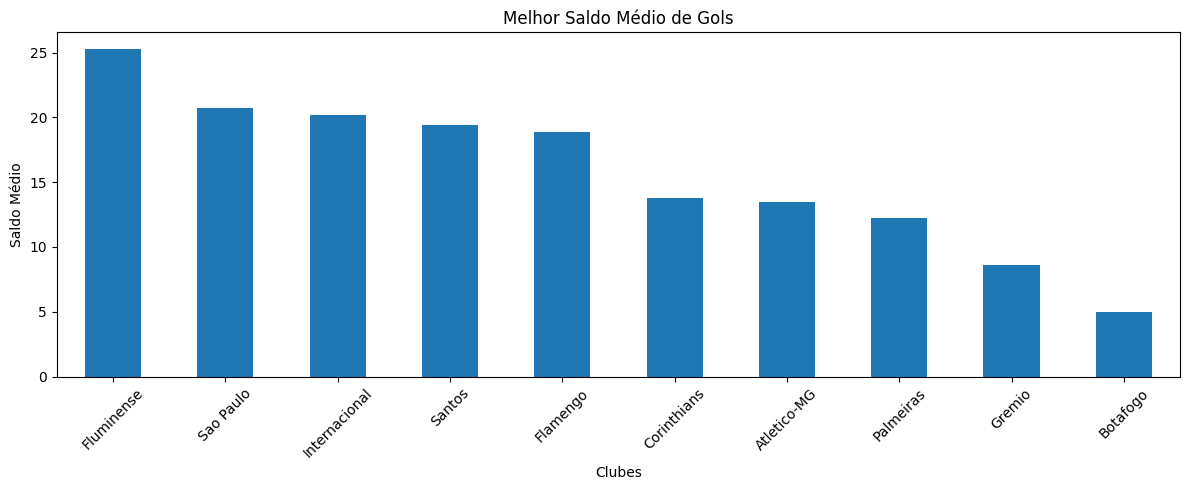

In [95]:
saldo = dados.groupby('Clube')['Saldo_Gols'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
saldo.head(10).plot(kind='bar')
plt.title('Melhor Saldo Médio de Gols')
plt.xlabel('Clubes')
plt.ylabel('Saldo Médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Distribuição de pontos

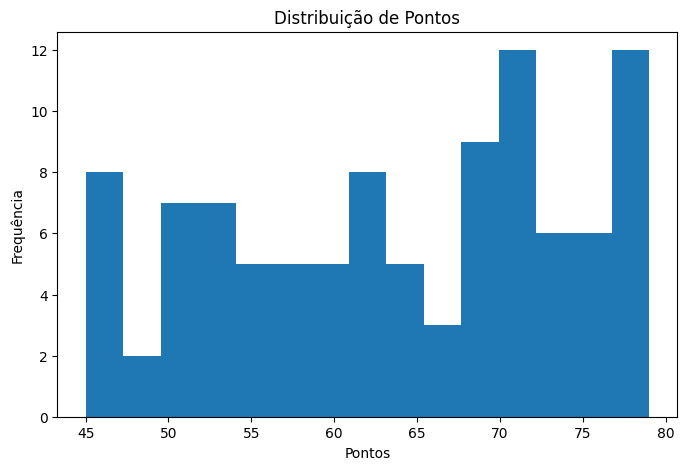

In [96]:
plt.figure(figsize=(8,5))
plt.hist(dados['Pontos'], bins=15)
plt.title('Distribuição de Pontos')
plt.xlabel('Pontos')
plt.ylabel('Frequência')
plt.show()

In [97]:
dados.to_csv('train_final.csv', index=False, encoding='utf-8-sig')

print("Arquivo salvo.")

Arquivo salvo.


- Os clubes com maior investimento tendem a conquistar mais pontos.
- Existe relação entre saldo de gols e posição final no campeonato.
- Alguns clubes apresentam consistência histórica em vitórias e títulos.
- O número de gols varia ao longo das temporadas.